# Dynamic Ridge vs. Nonlinear Models

Compare dynamic ridge, Extra Trees, and histogram gradient boosting using the same dynamic-context feature block and five game-grouped folds stratified by week. Categorical encoding and numeric imputation are learned inside each training fold. We compare route-level error, calibration, and receiver split-half reliability; no one metric alone determines the preferred model.

This is model selection using the 2021 season. The folds hold out whole games, but they do not replace a final future-season test.

In [1]:
from pathlib import Path
import html
import math
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from IPython.display import HTML, SVG, display
from separation_over_expected.reports import read_csv_rows

OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "algorithm_comparison"
METRICS = read_csv_rows(OUTPUT_DIR / "candidate_metrics.csv")
FOLDS = read_csv_rows(OUTPUT_DIR / "fold_metrics.csv")
DECILES = read_csv_rows(OUTPUT_DIR / "calibration_deciles.csv")
HALVES = read_csv_rows(OUTPUT_DIR / "receiver_half_scores.csv")
RELIABILITY = read_csv_rows(OUTPUT_DIR / "receiver_reliability.csv")
PREDICTIONS = read_csv_rows(OUTPUT_DIR / "route_oof_predictions.csv")
len(PREDICTIONS), len(METRICS), len(FOLDS), len(RELIABILITY)

## Check the paired split

Each model predicts the same route once, every game is assigned to exactly one validation fold, and the receiver reliability halves are shared across models.

In [1]:
from collections import Counter, defaultdict

route_keys = [(r["gameId"], r["playId"], r["nflId"]) for r in PREDICTIONS]
game_folds = defaultdict(set)
game_halves = defaultdict(set)
for row in PREDICTIONS:
    game_folds[(row["week"], row["gameId"])].add(row["fold"])
    game_halves[(row["week"], row["gameId"])].add(row["reliability_half"])
integrity = {
    "routes": len(PREDICTIONS), "unique routes": len(set(route_keys)),
    "games": len(game_folds),
    "games in multiple folds": sum(len(v) != 1 for v in game_folds.values()),
    "games in multiple halves": sum(len(v) != 1 for v in game_halves.values()),
    "fold route counts": dict(sorted(Counter(r["fold"] for r in PREDICTIONS).items())),
}
assert integrity["routes"] == integrity["unique routes"]
assert integrity["games in multiple folds"] == integrity["games in multiple halves"] == 0
integrity

## Route prediction

The bars show aggregate out-of-fold RMSE; points show MAE. Error bars show the standard deviation of fold RMSEs. Paired game-bootstrap intervals for RMSE changes from Ridge are summarized below.

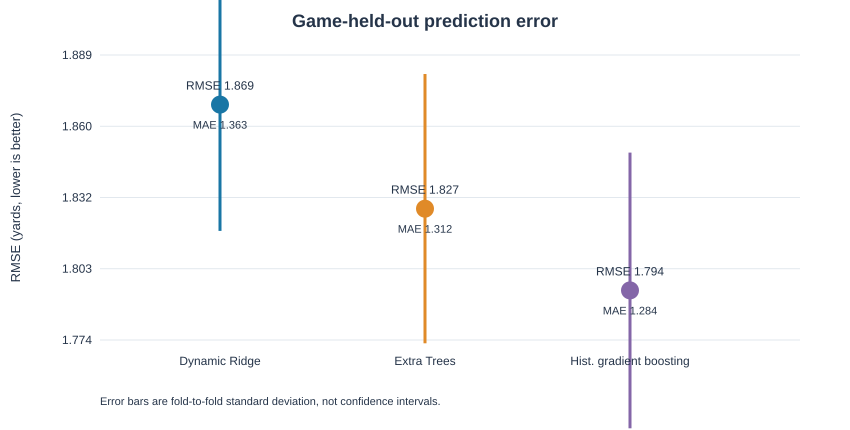

In [1]:
COLORS = {"ridge_dynamic_context": "#1976a5", "extra_trees": "#e08a28", "hist_gradient_boosting": "#8466a8"}
LABELS = {"ridge_dynamic_context": "Dynamic Ridge", "extra_trees": "Extra Trees", "hist_gradient_boosting": "Hist. gradient boosting"}

def error_plot(rows, folds, width=850, height=430):
    left, right, top, bottom = 100, 800, 55, 340
    lo = min(float(r["rmse"]) for r in rows) - 0.02
    hi = max(float(r["rmse"]) for r in rows) + 0.02
    y = lambda v: bottom - (float(v) - lo) / (hi - lo) * (bottom - top)
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
             '<rect width="100%" height="100%" fill="white"/>',
             '<style>text{font-family:Arial,sans-serif;fill:#253449}.grid{stroke:#e2e8ee}</style>',
             f'<text x="{width/2}" y="27" text-anchor="middle" font-size="18" font-weight="bold">Game-held-out prediction error</text>']
    for i in range(5):
        val = lo + i * (hi-lo) / 4
        yy = y(val)
        parts += [f'<line class="grid" x1="{left}" y1="{yy:.1f}" x2="{right}" y2="{yy:.1f}"/>',
                  f'<text x="{left-8}" y="{yy+4:.1f}" text-anchor="end" font-size="12">{val:.3f}</text>']
    for i, row in enumerate(rows):
        fold_values = [float(r["rmse"]) for r in folds if r["model"] == row["model"]]
        sd = (sum((v-sum(fold_values)/len(fold_values))**2 for v in fold_values)/(len(fold_values)-1))**0.5
        x = 220 + i * 205
        yy = y(row["rmse"])
        parts += [f'<line x1="{x}" y1="{y(float(row["rmse"])+sd):.1f}" x2="{x}" y2="{y(float(row["rmse"])-sd):.1f}" stroke="{COLORS[row["model"]]}" stroke-width="3"/>',
                  f'<circle cx="{x}" cy="{yy:.1f}" r="9" fill="{COLORS[row["model"]]}"/>',
                  f'<text x="{x}" y="{bottom+25}" text-anchor="middle" font-size="12">{LABELS[row["model"]]}</text>',
                  f'<text x="{x}" y="{yy-15:.1f}" text-anchor="middle" font-size="12">RMSE {float(row["rmse"]):.3f}</text>',
                  f'<text x="{x}" y="{yy+24:.1f}" text-anchor="middle" font-size="11">MAE {float(row["mae"]):.3f}</text>']
    parts += [f'<text x="20" y="{(top+bottom)/2}" text-anchor="middle" font-size="13" transform="rotate(-90 20 {(top+bottom)/2})">RMSE (yards, lower is better)</text>',
              '<text x="100" y="405" font-size="11">Error bars are fold-to-fold standard deviation, not confidence intervals.</text>', '</svg>']
    return "".join(parts)

display(SVG(error_plot(METRICS, FOLDS)))

## Receiver repeatability

Split-half Pearson correlation measures whether a receiver's residual level repeats across independent sets of games. The chart shows both each model's correlation and the paired change from Ridge, with receiver-bootstrap 95% intervals.

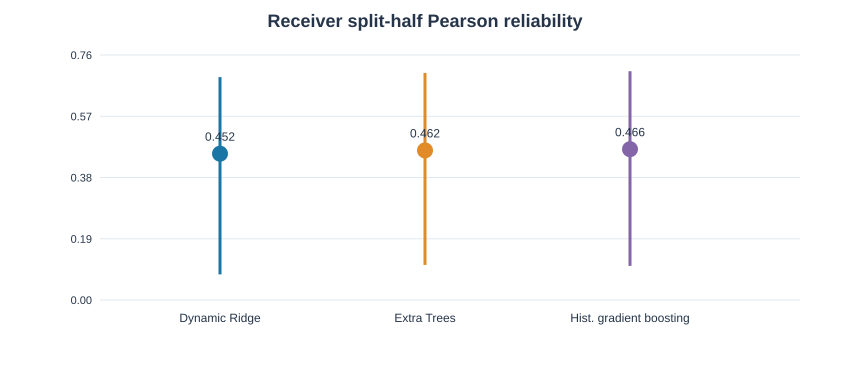

In [1]:
def reliability_plot(rows, width=850, height=390):
    left, right, top, bottom = 100, 800, 55, 300
    vals = [float(r["pearson_ci_lower"]) for r in rows] + [float(r["pearson_ci_upper"]) for r in rows]
    lo, hi = min(0, min(vals)-.05), max(vals)+.05
    y = lambda v: bottom - (float(v)-lo)/(hi-lo)*(bottom-top)
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
             '<rect width="100%" height="100%" fill="white"/>',
             '<style>text{font-family:Arial,sans-serif;fill:#253449}.grid{stroke:#e2e8ee}</style>',
             f'<text x="{width/2}" y="27" text-anchor="middle" font-size="18" font-weight="bold">Receiver split-half Pearson reliability</text>']
    for i in range(5):
        v=lo+(hi-lo)*i/4; yy=y(v)
        parts += [f'<line class="grid" x1="{left}" y1="{yy:.1f}" x2="{right}" y2="{yy:.1f}"/>',f'<text x="{left-8}" y="{yy+4:.1f}" text-anchor="end" font-size="11">{v:.2f}</text>']
    for i,row in enumerate(rows):
        x=220+i*205; yy=y(row["pearson"])
        parts += [f'<line x1="{x}" y1="{y(row["pearson_ci_lower"]):.1f}" x2="{x}" y2="{y(row["pearson_ci_upper"]):.1f}" stroke="{COLORS[row["model"]]}" stroke-width="3"/>',
                  f'<circle cx="{x}" cy="{yy:.1f}" r="8" fill="{COLORS[row["model"]]}"/>',
                  f'<text x="{x}" y="{bottom+22}" text-anchor="middle" font-size="12">{LABELS[row["model"]]}</text>',
                  f'<text x="{x}" y="{yy-13:.1f}" text-anchor="middle" font-size="12">{float(row["pearson"]):.3f}</text>']
    parts += ['</svg>']; return "".join(parts)

display(SVG(reliability_plot(RELIABILITY)))

## Calibration

Decile points show mean predicted versus observed separation change; the diagonal is ideal calibration. The goal is not merely a higher R²: a candidate should also preserve meaningful calibration and receiver repeatability.

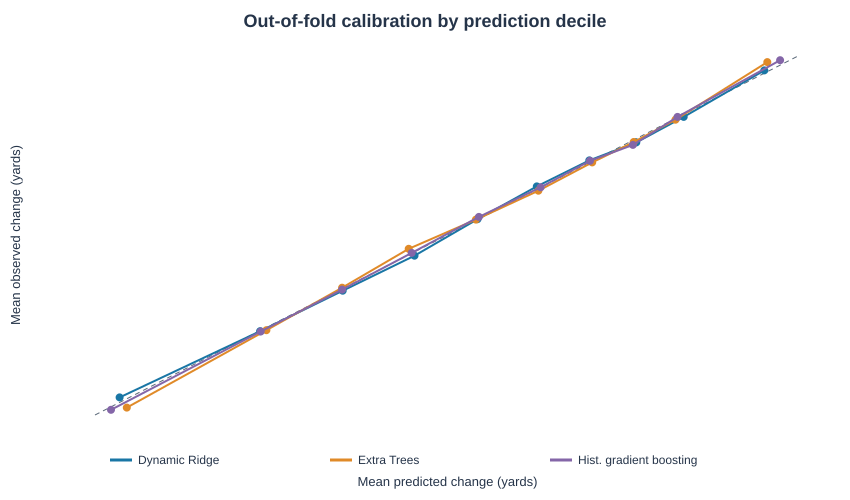

In [1]:
def calibration_plot(rows, width=850, height=500):
    lo=min(float(r[k]) for r in rows for k in ("mean_predicted","mean_actual"))-.1
    hi=max(float(r[k]) for r in rows for k in ("mean_predicted","mean_actual"))+.1
    left,right,top,bottom=95,800,55,415
    x=lambda v:left+(float(v)-lo)/(hi-lo)*(right-left)
    y=lambda v:bottom-(float(v)-lo)/(hi-lo)*(bottom-top)
    parts=[f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">','<rect width="100%" height="100%" fill="white"/>','<style>text{font-family:Arial,sans-serif;fill:#253449}.grid{stroke:#e2e8ee}</style>',f'<text x="{width/2}" y="27" text-anchor="middle" font-size="18" font-weight="bold">Out-of-fold calibration by prediction decile</text>']
    parts += [f'<line x1="{x(lo):.1f}" y1="{y(lo):.1f}" x2="{x(hi):.1f}" y2="{y(hi):.1f}" stroke="#596878" stroke-dasharray="5 4"/>']
    for model in LABELS:
        selected=sorted((r for r in rows if r["model"]==model),key=lambda r:int(r["decile"]))
        pts=[]
        for row in selected:
            xx,yy=x(row["mean_predicted"]),y(row["mean_actual"]);pts.append(f"{xx:.1f},{yy:.1f}")
            parts.append(f'<circle cx="{xx:.1f}" cy="{yy:.1f}" r="4" fill="{COLORS[model]}"/>')
        parts.append(f'<polyline points="{" ".join(pts)}" fill="none" stroke="{COLORS[model]}" stroke-width="2"/>')
    for i,model in enumerate(LABELS):
        parts.append(f'<line x1="{110+i*220}" y1="460" x2="{132+i*220}" y2="460" stroke="{COLORS[model]}" stroke-width="3"/><text x="{138+i*220}" y="464" font-size="12">{LABELS[model]}</text>')
    parts += [f'<text x="{(left+right)/2}" y="{height-14}" text-anchor="middle" font-size="13">Mean predicted change (yards)</text>',f'<text x="20" y="{(top+bottom)/2}" text-anchor="middle" font-size="13" transform="rotate(-90 20 {(top+bottom)/2})">Mean observed change (yards)</text>','</svg>']
    return "".join(parts)

display(SVG(calibration_plot(DECILES)))

## Results table and interpretation

Negative paired RMSE change favors the nonlinear model. Treat its game-bootstrap interval as the uncertainty around the route-error difference; receiver-bootstrap intervals describe repeatability.

In [1]:
def table(rows, fields):
    header="".join(f'<th style="padding:5px;border-bottom:2px solid #ccd5de;text-align:left">{html.escape(label)}</th>' for label,key in fields)
    body="".join('<tr>'+''.join(f'<td style="padding:4px 6px;border-bottom:1px solid #e4e9ef">{html.escape(str(row.get(key,"")))}</td>' for _,key in fields)+'</tr>' for row in rows)
    return HTML(f'<table style="border-collapse:collapse"><thead><tr>{header}</tr></thead><tbody>{body}</tbody></table>')

table(METRICS, [("Model","model"),("RMSE","rmse"),("MAE","mae"),("R²","r2"),("RMSE change vs Ridge [95% game CI]","rmse_delta_vs_ridge"),("CI lower","rmse_delta_lower_95"),("CI upper","rmse_delta_upper_95"),("Calibration slope","calibration_slope"),("Mean absolute decile bias","mean_absolute_decile_bias")])

Model,RMSE,MAE,R²,RMSE change vs Ridge [95% game CI],CI lower,CI upper,Calibration slope,Mean absolute decile bias
ridge_dynamic_context,1.869,1.363,0.508,0.0,0.0,0.0,0.99715629,0.05065246
extra_trees,1.827,1.312,0.530,-0.04195970506766389,-0.052556855770769406,-0.03164872891857362,1.03037913,0.06838241
hist_gradient_boosting,1.794,1.284,0.547,-0.07495509565623348,-0.0882657108077094,-0.06227516509277842,1.01280003,0.03662699


In [1]:
table(RELIABILITY, [("Model","model"),("Pearson","pearson"),("Pearson 95% lower","pearson_ci_lower"),("Pearson 95% upper","pearson_ci_upper"),("Pearson delta vs Ridge","pearson_delta_vs_ridge"),("Paired delta lower","pearson_delta_lower_95"),("Paired delta upper","pearson_delta_upper_95"),("Eligible receivers","eligible_receivers")])

Model,Pearson,Pearson 95% lower,Pearson 95% upper,Pearson delta vs Ridge,Paired delta lower,Paired delta upper,Eligible receivers
ridge_dynamic_context,0.451857,0.079076,0.688689,0,0,0,115
extra_trees,0.462143,0.108312,0.701696,0.010286,-0.065212,0.090557,115
hist_gradient_boosting,0.465955,0.105227,0.706839,0.014098,-0.078247,0.113394,115


## Interpretation

Both nonlinear models improve route prediction over dynamic Ridge on these held-out games. Histogram gradient boosting reduces RMSE by 0.075 yards (paired game-bootstrap 95% interval: -0.088 to -0.062) and Extra Trees by 0.042 yards (-0.053 to -0.032). Histogram gradient boosting also has the lowest MAE (1.284 vs. 1.363) and a calibration slope near 1 (1.013). Its mean absolute decile bias is lower than Ridge's in this run (0.037 vs. 0.051 yards). Extra Trees has a slope of 1.030 and higher decile bias (0.068).

Receiver repeatability is less conclusive. Pearson reliability rises from 0.452 for Ridge to 0.466 for histogram gradient boosting, but the paired receiver-bootstrap interval for the difference (-0.078 to 0.113) includes zero. Spearman rises from 0.209 to 0.288, also with a paired interval crossing zero (-0.022 to 0.182). The models therefore show a clear route-level prediction gain, but not yet a demonstrated receiver-level reliability gain.

Treat histogram gradient boosting as the leading challenger, not a replacement for Ridge. These hyperparameters were chosen as reasonable starting points rather than tuned on a separate validation set. Next tune its complexity using nested/validation folds, then test the selected model on a season that was not used for selection. That external check must use only features with consistent definitions in both seasons.